# Analysis of interaction grouping using tSNE (2014)

In [1]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocess title embeddings for tSNE

In [2]:
df_emb = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.inter', sep='\t')
df_emb.head(5)

,user_id:token,item_id:token,rating:float,timestamp:float
0,0,0,5.0,1390694400
1,1,0,5.0,1328140800
2,2,0,4.0,1330387200
3,3,0,4.0,1328400000
4,4,0,4.0,1366675200


In [3]:
n_users = df_emb['user_id:token'].nunique()
n_items = df_emb['item_id:token'].nunique()

users = df_emb['user_id:token'].unique()
items = df_emb['item_id:token'].unique()

reverse_users = {user_id: idx for idx, user_id in enumerate(users)}
reverse_items = {item_id: idx for idx, item_id in enumerate(items)}

inter_matrix = np.ndarray((n_users, n_items))

inter_matrix[:10]
print(f'Interaction matrix shape: {inter_matrix.shape}')

Interaction matrix shape: (35598, 18357)


In [4]:
for i, row in df_emb.iterrows():
    user_id = int(row['user_id:token'])
    item_id = int(row['item_id:token'])

    inter_matrix[reverse_users[user_id]][reverse_items[item_id]] = 1

In [5]:
df_emb = pd.DataFrame()
df_emb['id'] = items
df_emb['emb'] = list(inter_matrix.T)

In [6]:
df_cat = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df_cat.head(5)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,0,Ghost Inc Glock Armorers Tool 3/32 Punch,9.99,Ghost,"'Sports & Outdoors', 'Hunting', 'Hunting & Fis...",Sports &amp; Outdoors,532941.0
1,1,5 LED Bicycle Rear Tail Red Bike Torch Laser B...,8.26,NaN,"'Lights & Reflectors', 'Sports & Outdoors', 'C...",Toys & Games,15617.0
2,3,Black Mountain Products Resistance Band Set wi...,32.99,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0
3,2,Black Mountain Products Single Resistance Band...,10.49,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0
4,4,Outers Universal 32-Piece Blow Molded Gun Clea...,21.99,Outers,"'Sports & Outdoors', 'Hunting', 'Gun Cleaning ...",Sports &amp; Outdoors,26457.0


In [7]:
df_cat = df_cat.rename(columns={"categories:token_seq": "cat", "item_id:token": "id"})
df_cat['cat'] = df_cat['cat'].apply(lambda x: [entry for entry in str(x).split(',')])
df_cat.drop(columns=['price:float', 'title:token', 'sales_rank:float', 'sales_type:token'], inplace=True)
df_cat.head(5)

,id,brand:token,cat
0,0,Ghost,"['Sports & Outdoors', 'Hunting', 'Hunting & ..."
1,1,NaN,"['Lights & Reflectors', 'Sports & Outdoors', ..."
2,3,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ..."
3,2,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ..."
4,4,Outers,"['Sports & Outdoors', 'Hunting', 'Gun Cleani..."


## 2. Create colour column

In [8]:
categories_2d = df_cat['cat'].tolist()

categories = []
for entry in categories_2d:
    for cat in entry:
        categories.append(cat)

categories = set(categories)

In [9]:
colour_dict = {cat: np.random.randint(0, 256, size=3) for cat in categories}

def rgb_mean(cat_list):
    arr = np.array([colour_dict[x] for x in cat_list])
    return arr.mean(axis=0)

In [10]:
df_cat['colour'] = df_cat['cat'].apply(rgb_mean)
df_cat.head(5)

,id,brand:token,cat,colour
0,0,Ghost,"['Sports & Outdoors', 'Hunting', 'Hunting & ...","[186.6, 83.4, 120.4]"
1,1,NaN,"['Lights & Reflectors', 'Sports & Outdoors', ...","[63.75, 118.75, 84.25]"
2,3,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ...","[174.75, 67.75, 172.25]"
3,2,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ...","[174.75, 67.75, 172.25]"
4,4,Outers,"['Sports & Outdoors', 'Hunting', 'Gun Cleani...","[169.2, 101.4, 141.6]"


## 3. Sample items and analise with tSNE

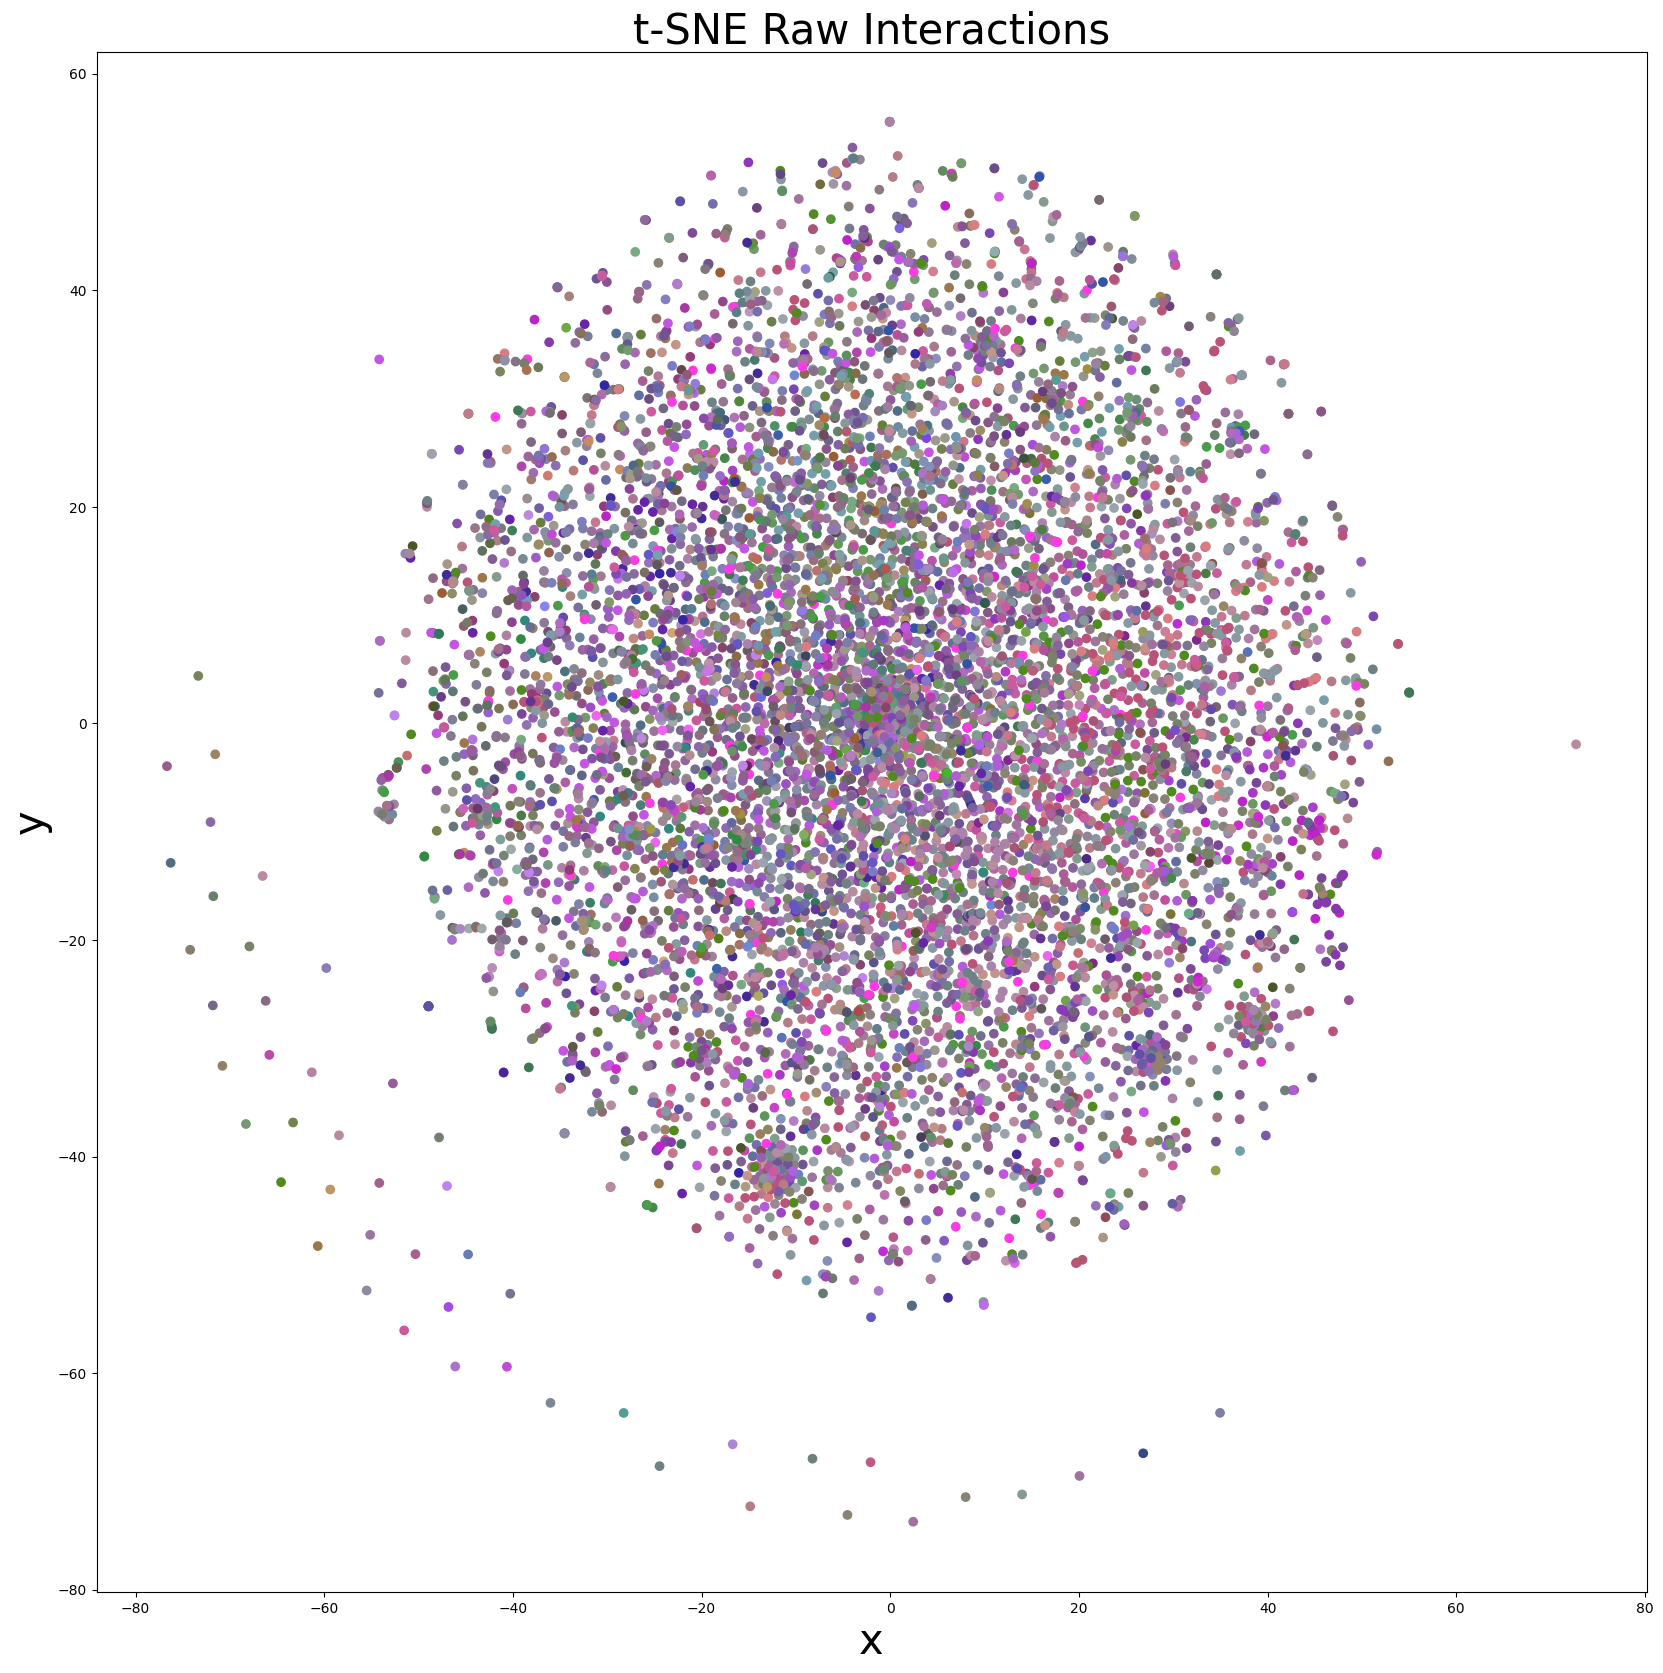

In [12]:
SAMPLE_SIZE = 10000
import umap.umap_ as umap

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

#X_emb = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1).fit_transform(X)
X_emb = TSNE(n_components=2, perplexity=32).fit_transform(X)
plt.figure(figsize=(20, 20))
plt.title(f't-SNE Raw Interactions', fontsize=30)
plt.xlabel('x', fontsize=30)
plt.ylabel('y', fontsize=30)
plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind] / 255.0)
plt.show()